<a href="https://colab.research.google.com/github/Cho-minjeong/DL_26_01_Team6/blob/main/recycle_project_%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 0. 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. 라이브러리
import os
import shutil
import random

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# 2. 폴더 생성
base_path = '/content/drive/MyDrive/recycle_project/dataset'

folders = ['train', 'valid', 'test']

classes = ['glass', 'paper', 'cardboard',
           'plastic', 'metal', 'trash']

for folder in folders:

    for cls in classes:

        path = os.path.join(base_path, folder, cls)

        os.makedirs(path, exist_ok=True)

print("폴더 생성 완료")

폴더 생성 완료


In [ ]:
# 3. Trashnet 데이터셋 다운로드 및 압축 해제
!wget -N https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip
!unzip -q -o dataset-resized.zip -d /content/drive/MyDrive/recycle_project/

--2026-06-01 17:22:06--  https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/garythung/trashnet/master/data/dataset-resized.zip [following]
--2026-06-01 17:22:06--  https://raw.githubusercontent.com/garythung/trashnet/master/data/dataset-resized.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42834870 (41M) [application/zip]
Saving to: ‘dataset-resized.zip’

dataset-resized.zip 100%[===================>]  40.85M   240MB/s    in 0.2s    

Last-modified header missing -- time-stamps turned off.
2026-06-01 17:22:06 (240 MB/s)

In [ ]:
# 4. 데이터 자동 분할
source_path = '/content/drive/MyDrive/recycle_project/dataset-resized'

classes = ['glass', 'paper', 'cardboard',
           'plastic', 'metal', 'trash']

for cls in classes:

    files = [
        f for f in os.listdir(os.path.join(source_path, cls))
        if f.endswith(('.jpg', '.jpeg', '.png'))
    ]

    random.shuffle(files)

    train_size = int(len(files) * 0.8)
    valid_size = int(len(files) * 0.1)

    train_files = files[:train_size]
    valid_files = files[train_size:train_size+valid_size]
    test_files = files[train_size+valid_size:]

    for file in train_files:

        shutil.copy(
            os.path.join(source_path, cls, file),
            os.path.join(base_path, 'train', cls, file)
        )

    for file in valid_files:

        shutil.copy(
            os.path.join(source_path, cls, file),
            os.path.join(base_path, 'valid', cls, file)
        )

    for file in test_files:

        shutil.copy(
            os.path.join(source_path, cls, file),
            os.path.join(base_path, 'test', cls, file)
        )

print("데이터 분할 완료")

데이터 분할 완료


In [ ]:
# 5. 이미지 전처리
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])

In [ ]:
# 6. 데이터셋 가져오기
train_data = datasets.ImageFolder(
    base_path + '/train',
    transform=transform
)

valid_data = datasets.ImageFolder(
    base_path + '/valid',
    transform=transform
)

test_data = datasets.ImageFolder(
    base_path + '/test',
    transform=transform
)

print(len(train_data))
print(len(valid_data))
print(len(test_data))

2019
251
257


In [ ]:
# 7. DataLoader 생성
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_data,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

In [ ]:
# 8. ResNet50 모델 생성
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


In [ ]:
# 9. 출력층 수정
model.fc = nn.Linear(model.fc.in_features, 6)

In [ ]:
# 10. 손실함수
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
# 11. 모델학습
epochs = 20
model = model.to(device)
for epoch in range(epochs):

    running_loss = 0

    model.train()

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch {epoch+1}, Loss: {running_loss:.4f}')

Epoch 1, Loss: 40.0224
Epoch 2, Loss: 11.4120
Epoch 3, Loss: 5.4838
Epoch 4, Loss: 4.7311
Epoch 5, Loss: 4.7974
Epoch 6, Loss: 6.0055
Epoch 7, Loss: 3.8371
Epoch 8, Loss: 4.3995
Epoch 9, Loss: 2.8115
Epoch 10, Loss: 3.4720
Epoch 11, Loss: 3.4412
Epoch 12, Loss: 3.4351
Epoch 13, Loss: 6.3058
Epoch 14, Loss: 4.0527
Epoch 15, Loss: 3.8988
Epoch 16, Loss: 4.0753
Epoch 17, Loss: 2.7427
Epoch 18, Loss: 4.4756
Epoch 19, Loss: 4.7464
Epoch 20, Loss: 4.2995


In [ ]:
# 12. 모델 복사
import copy
model_trashnet = copy.deepcopy(model)

In [ ]:
# 13. 정확도 평가
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f'정확도: {accuracy:.2f}%')

정확도: 92.61%


In [ ]:
# 14. 정확도, Precision, Recall, F1-score, Confusion Matrix
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

trashnet_preds = []
trashnet_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        trashnet_preds.extend(predicted.cpu().numpy())
        trashnet_labels.extend(labels.cpu().numpy())

# 1. Accuracy 계산
accuracy = 100 * np.sum(np.array(trashnet_preds) == np.array(trashnet_labels)) / len(trashnet_labels)

# 2. Precision, Recall, F1-score
precision = precision_score(trashnet_labels, trashnet_preds, average='macro')
recall = recall_score(trashnet_labels, trashnet_preds, average='macro')
f1 = f1_score(trashnet_labels, trashnet_preds, average='macro')

# 3. Confusion Matrix
confusion_matrix = confusion_matrix(trashnet_labels, trashnet_preds)

print(f'정확도: {accuracy:.2f}%')
print(f'Precision (Macro): {precision:.4f}')
print(f'Recall (Macro): {recall:.4f}')
print(f'F1-score (Macro): {f1:.4f}')
print('\n[Confusion Matrix]')
print(confusion_matrix)

# 4. 클래스별 상세 레포트 출력
print('\n[Classification Report]')
print(classification_report(trashnet_labels, trashnet_preds, target_names=classes))

정확도: 92.61%
Precision (Macro): 0.9283
Recall (Macro): 0.9118
F1-score (Macro): 0.9183

[Confusion Matrix]
[[39  0  1  1  0  0]
 [ 0 44  1  1  5  0]
 [ 0  0 40  0  1  0]
 [ 1  0  0 59  0  0]
 [ 0  1  2  1 44  1]
 [ 0  0  0  2  1 12]]

[Classification Report]
              precision    recall  f1-score   support

       glass       0.97      0.95      0.96        41
       paper       0.98      0.86      0.92        51
   cardboard       0.91      0.98      0.94        41
     plastic       0.92      0.98      0.95        60
       metal       0.86      0.90      0.88        49
       trash       0.92      0.80      0.86        15

    accuracy                           0.93       257
   macro avg       0.93      0.91      0.92       257
weighted avg       0.93      0.93      0.93       257



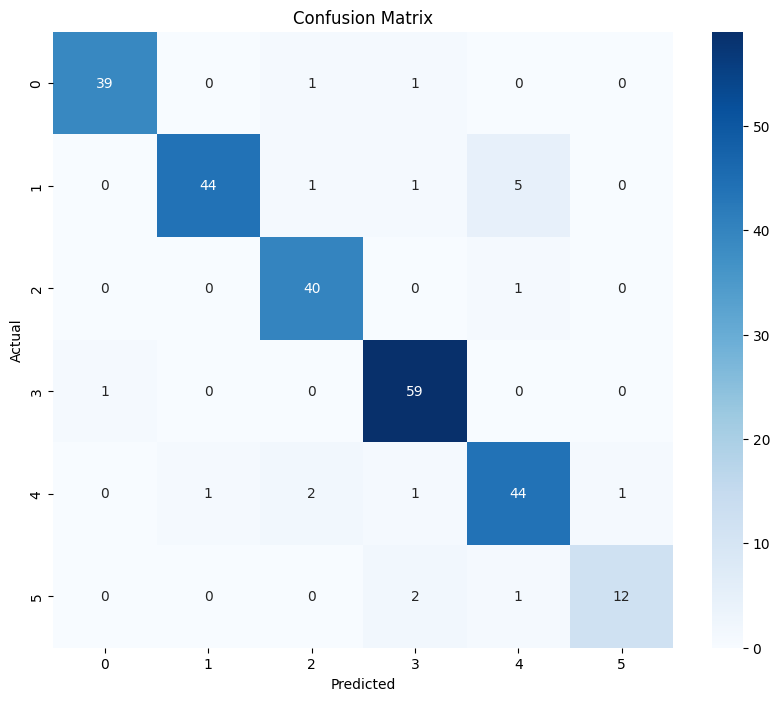

In [ ]:
# 15. Confusion Matrix 그래프
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# 16. TACO 다운로드
import os
import shutil

%cd /content

taco_drive_dir = '/content/drive/MyDrive/recycle_project/taco_dataset'
os.makedirs(taco_drive_dir, exist_ok=True)

if os.path.exists('/content/TACO_repo'):
    !rm -rf /content/TACO_repo

print("📥 TACO 레포지토리를 다운로드합니다...")
!git clone https://github.com/pedropro/TACO.git /content/TACO_repo

if os.path.exists('/content/TACO_repo/data/annotations.json'):
    !cp /content/TACO_repo/data/annotations.json {taco_drive_dir}/annotations.json
else:
    print(" 레포지토리 다운로드에 문제가 발생했습니다. 셀을 다시 실행해 주세요.")

%cd /content/TACO_repo

!python3 download.py --dataset_path {taco_drive_dir}/annotations.json

print("모든 이미지 다운")

/content
📥 TACO 레포지토리를 다운로드합니다...
Cloning into '/content/TACO_repo'...
remote: Enumerating objects: 740, done.
remote: Counting objects: 100% (435/435), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 740 (delta 416), reused 380 (delta 380), pack-reused 305 (from 1)
Receiving objects: 100% (740/740), 97.48 MiB | 24.26 MiB/s, done.
Resolving deltas: 100% (499/499), done.
/content/TACO_repo
Note. If for any reason the connection is broken. Just call me again and I will start where I left.
Finished
모든 이미지 다운


In [ ]:
# 17. TACO 데이터 파이프라인 구축
# TACO 데이터 매핑
import json
import numpy as np
from torch.utils.data import Dataset, Subset, DataLoader
from PIL import Image

class TACO_Drive_6Classes(Dataset):
    def __init__(self, taco_dir, transform=None):
        self.taco_dir = taco_dir
        self.transform = transform

        json_path = os.path.join(taco_dir, 'annotations.json')
        with open(json_path, 'r') as f:
            self.taco_data = json.load(f)

        taco_categories = {cat['id']: cat['name'].lower() for cat in self.taco_data['categories']}
        self.category_mapping = {}

        for cat_id, cat_name in taco_categories.items():
            if 'cardboard' in cat_name: self.category_mapping[cat_id] = 2
            elif 'paper' in cat_name or 'magazine' in cat_name: self.category_mapping[cat_id] = 1
            elif any(p in cat_name for p in ['plastic', 'pet', 'polypropylene', 'styrofoam', 'film', 'bottle']): self.category_mapping[cat_id] = 3
            elif any(m in cat_name for m in ['can', 'aluminium', 'metal']): self.category_mapping[cat_id] = 4
            elif 'glass' in cat_name: self.category_mapping[cat_id] = 0
            else: self.category_mapping[cat_id] = 5 # 나머지는 전부 trash

        img_id_to_class = {}
        for ann in self.taco_data['annotations']:
            img_id = ann['image_id']
            cat_id = ann['category_id']
            if img_id not in img_id_to_class:
                img_id_to_class[img_id] = self.category_mapping.get(cat_id, 5)

        self.img_list = []
        for img in self.taco_data['images']:
            if img['id'] in img_id_to_class:
                full_img_path = os.path.join(taco_dir, img['file_name'])
                self.img_list.append({
                    'path': full_img_path,
                    'label': img_id_to_class[img['id']]
                })

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_info = self.img_list[idx]
        try:
            image = Image.open(img_info['path']).convert('RGB')
        except FileNotFoundError:
            image = Image.new('RGB', (224, 224), color=(0, 0, 0))
        if self.transform:
            image = self.transform(image)
        return image, img_info['label']

In [ ]:
# 18. 데이터셋 인스턴스 생성 및 메모리 분할
taco_drive_dataset = TACO_Drive_6Classes('/content/drive/MyDrive/recycle_project/taco_dataset', transform=transform)

taco_size = len(taco_drive_dataset)
taco_indices = list(range(taco_size))

np.random.seed(42)
np.random.shuffle(taco_indices)

taco_train_split = int(np.floor(0.8 * taco_size))
taco_valid_split = int(np.floor(0.9 * taco_size))

taco_train_idx = taco_indices[:taco_train_split]
taco_valid_idx = taco_indices[taco_train_split:taco_valid_split]
taco_test_idx = taco_indices[taco_valid_split:]

taco_train_data = Subset(taco_drive_dataset, taco_train_idx)
taco_valid_data = Subset(taco_drive_dataset, taco_valid_idx)
taco_test_data = Subset(taco_drive_dataset, taco_test_idx)

taco_train_loader = DataLoader(taco_train_data, batch_size=32, shuffle=True)
taco_valid_loader = DataLoader(taco_valid_data, batch_size=32, shuffle=False)
taco_test_loader = DataLoader(taco_test_data, batch_size=32, shuffle=False)

print("데이터 분할 완료")
print(len(taco_train_data))
print(len(taco_valid_data))
print(len(taco_test_data))

데이터 분할 완료
1200
150
150


In [ ]:
# 19. 1차 학습 모델 기반 실제 환경 데이터 정확도 평가
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import torch

trashnet_taco_preds = []
trashnet_taco_labels = []

target_names = ['Glass', 'Paper', 'Cardboard', 'Plastic', 'Metal', 'Trash']

model.eval()

print("1차 학습 모델(TrashNet)로 TACO 테스트 데이터를 상세 평가")

with torch.no_grad():
    for images, labels in taco_test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_trashnet(images)
        _, predicted = torch.max(outputs, 1)

        trashnet_taco_preds.extend(predicted.cpu().numpy())
        trashnet_taco_labels.extend(labels.cpu().numpy())

# 1. Accuracy 계산
accuracy = 100 * np.sum(np.array(trashnet_taco_preds) == np.array(trashnet_taco_labels)) / len(trashnet_taco_labels)

# 2. Precision, Recall, F1-score
precision = precision_score(trashnet_taco_labels, trashnet_taco_preds, average='macro', zero_division=0)
recall = recall_score(trashnet_taco_labels, trashnet_taco_preds, average='macro',  zero_division=0)
f1 = f1_score(trashnet_taco_labels, trashnet_taco_preds, average='macro', zero_division=0)

# 3. Confusion Matrix
confusion_matrix = confusion_matrix(trashnet_taco_labels, trashnet_taco_preds, labels=[0, 1, 2, 3, 4, 5])

print(f'정확도: {accuracy:.2f}%')
print(f'Precision (Macro): {precision:.4f}')
print(f'Recall (Macro): {recall:.4f}')
print(f'F1-score (Macro): {f1:.4f}')
print('\n[Confusion Matrix]')
print(confusion_matrix)


# 4. 클래스별 상세 레포트 출력
print('\n[Classification Report]')
print(classification_report(trashnet_taco_labels, trashnet_taco_preds,
    labels=[0, 1, 2, 3, 4, 5], target_names=target_names, zero_division=0))

1차 학습 모델(TrashNet)로 TACO 테스트 데이터를 상세 평가
정확도: 22.67%
Precision (Macro): 0.2161
Recall (Macro): 0.1413
F1-score (Macro): 0.1443

[Confusion Matrix]
[[ 0  0  0  0  0  0]
 [ 2  1  2  2  0  0]
 [ 0  0  0  0  0  0]
 [17 14 18 23 21  5]
 [ 2  2  6  3  7  0]
 [ 2  5  4  7  4  3]]

[Classification Report]
              precision    recall  f1-score   support

       Glass       0.00      0.00      0.00         0
       Paper       0.05      0.14      0.07         7
   Cardboard       0.00      0.00      0.00         0
     Plastic       0.66      0.23      0.35        98
       Metal       0.22      0.35      0.27        20
       Trash       0.38      0.12      0.18        25

    accuracy                           0.23       150
   macro avg       0.22      0.14      0.14       150
weighted avg       0.52      0.23      0.30       150



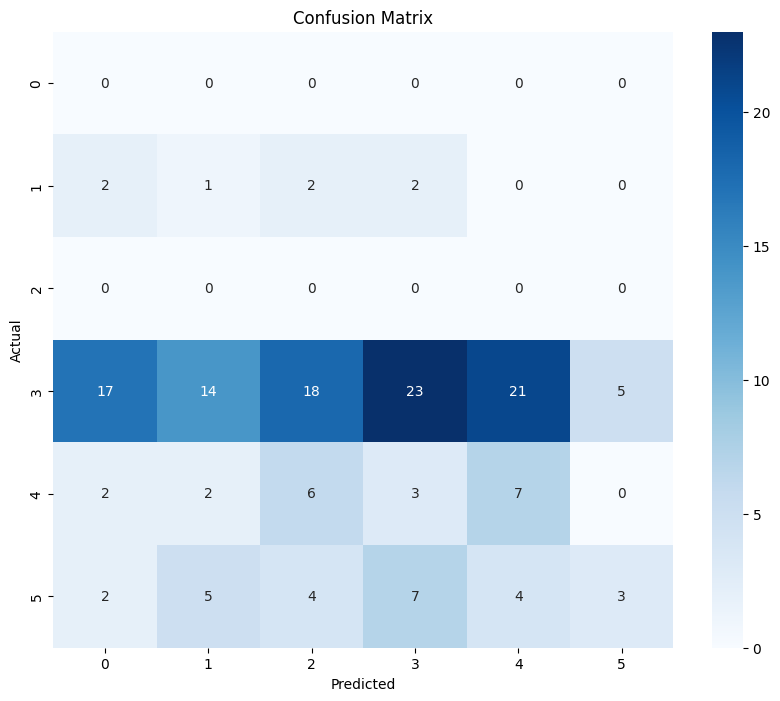

In [ ]:
# 20. Confusion Matrix 그래프
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# 21. 손실함수
import torch.optim as optim
import torch.nn as nn

for param in model.parameters():
    param.requires_grad = True

optimizer_taco = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

In [ ]:
# 22. 2차 학습 (TACO 데이터)

epochs = 20

for epoch in range(epochs):
    running_loss = 0
    model.train()
    for images, labels in taco_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_taco.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer_taco.step()
        running_loss += loss.item()
    print(f'TACO Epoch {epoch+1}, Loss: {running_loss:.4f}')

TACO Epoch 1, Loss: 42.8765
TACO Epoch 2, Loss: 26.9084
TACO Epoch 3, Loss: 8.0446
TACO Epoch 4, Loss: 3.6384
TACO Epoch 5, Loss: 2.7468
TACO Epoch 6, Loss: 2.8655
TACO Epoch 7, Loss: 1.8489
TACO Epoch 8, Loss: 2.8688
TACO Epoch 9, Loss: 1.6328
TACO Epoch 10, Loss: 1.7269
TACO Epoch 11, Loss: 1.8027
TACO Epoch 12, Loss: 1.8305
TACO Epoch 13, Loss: 1.9953
TACO Epoch 14, Loss: 1.4171
TACO Epoch 15, Loss: 1.9759
TACO Epoch 16, Loss: 0.6550
TACO Epoch 17, Loss: 0.5539
TACO Epoch 18, Loss: 0.7466
TACO Epoch 19, Loss: 0.6394
TACO Epoch 20, Loss: 0.4954


In [ ]:
# 23. 정확도 평가
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in taco_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f'2차 학습 후 정확도: {accuracy:.2f}%')

2차 학습 후 정확도: 64.00%


In [ ]:
# 24. 2차 학습 후 정확도, Precision, Recall, F1-score, Confusion Matrix
from sklearn.metrics import  precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import torch

model.eval()

Taco_preds = []
Taco_labels = []

with torch.no_grad():
    for images, labels in taco_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        Taco_preds.extend(preds.cpu().numpy())
        Taco_labels.extend(labels.cpu().numpy())

# 1. Accuracy 계산
accuracy = 100 * np.sum(np.array(Taco_preds) == np.array(Taco_labels)) / len(Taco_labels)

# 2. Precision, Recall, F1-score
precision = precision_score(Taco_labels, Taco_preds, average='macro', zero_division=0)
recall = recall_score(Taco_labels, Taco_preds, average='macro',  zero_division=0)
f1 = f1_score(Taco_labels, Taco_preds, average='macro', zero_division=0)

# 3. Confusion Matrix
confusion_mat = confusion_matrix(Taco_labels, Taco_preds, labels=[0, 1, 2, 3, 4, 5])

print(f'정확도: {accuracy:.2f}%')
print(f'Precision (Macro): {precision:.4f}')
print(f'Recall (Macro): {recall:.4f}')
print(f'F1-score (Macro): {f1:.4f}')
print('\n[Confusion Matrix]')
print(confusion_mat)


# 4. 클래스별 상세 레포트 출력
print('\n[Classification Report]')
print(classification_report(Taco_labels, Taco_preds,
    labels=[0, 1, 2, 3, 4, 5], target_names=target_names, zero_division=0))
print(classification_report(Taco_labels,Taco_preds))

정확도: 64.00%
Precision (Macro): 0.4401
Recall (Macro): 0.3741
F1-score (Macro): 0.3728

[Confusion Matrix]
[[ 0  0  0  0  0  0]
 [ 0  0  0  5  0  2]
 [ 0  0  0  0  0  0]
 [ 0  1  0 80  2 15]
 [ 0  0  0 11  4  5]
 [ 0  1  0 12  0 12]]

[Classification Report]
              precision    recall  f1-score   support

       Glass       0.00      0.00      0.00         0
       Paper       0.00      0.00      0.00         7
   Cardboard       0.00      0.00      0.00         0
     Plastic       0.74      0.82      0.78        98
       Metal       0.67      0.20      0.31        20
       Trash       0.35      0.48      0.41        25

    accuracy                           0.64       150
   macro avg       0.29      0.25      0.25       150
weighted avg       0.63      0.64      0.62       150

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         7
           3       0.74      0.82      0.78        98
           4       0.67      0.20   

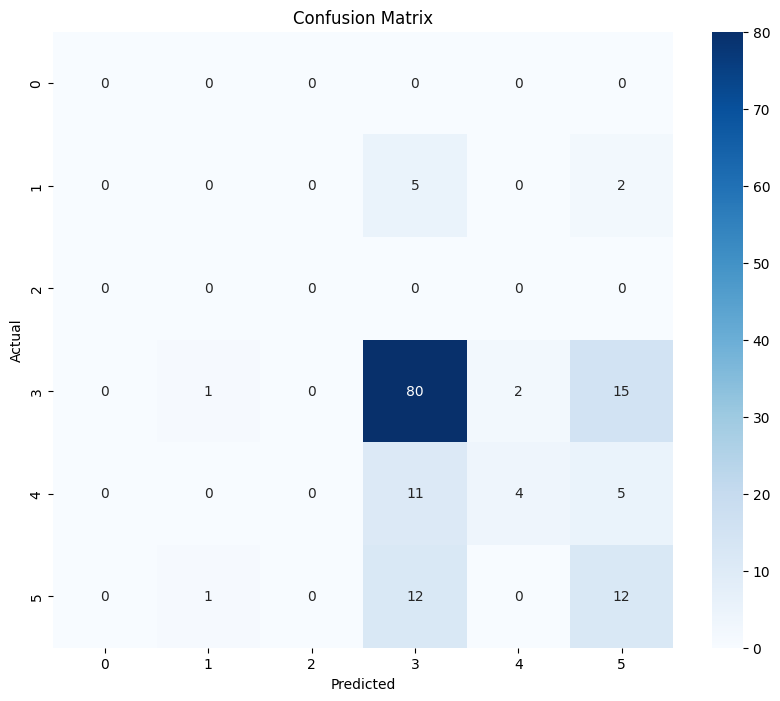

In [ ]:
# 25. Confusion Matrix 그래프
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# 26. 모델 저장

torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/recycle_project/model_v2.pth"
)

print("모델 저장 완료")

모델 저장 완료
